In [5]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.append('/home/yuliya/repos/cosybio/FedProt/evaluation_utils/')
from evaluation import evaluation_func as fp_eval

from collections import OrderedDict

# Config

In [6]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled"

fedprot_name="DPE.tsv"
deqms_name="res.tsv"
fisher_name="MA_CM.tsv"
rem_name="MA_REM.tsv"
stouffer_name="MA_Stouffer.tsv"
rankprod_name="MA_RankProd.tsv"

number_of_runs = 11
lfc_thr = 1
pval_thr = 0.05


# balanced - balanced -- CHANGE!
# fedprot_name="DPE.tsv"

In [7]:
def read_data(workdir, prefix):
    df = fp_eval.read_results(
                workdir, 
                fedprot_name=f"{prefix}{fedprot_name}",
                deqms_name=f"{prefix}{deqms_name}",
                fisher_name=f"{prefix}{fisher_name}",
                rem_name=f"{prefix}{rem_name}",
                stouffer_name=f"{prefix}{stouffer_name}",
                rankprod_name=f"{prefix}{rankprod_name}"
    )
    return df

def log_transform_df(df):
    df = df.replace(0,1e-300)
    # replace all smaller than 1e-300 with 1e-300 in all columns
    for c in df.columns:
        df.loc[df[c] < 1e-300, c] = 1e-300
    df["pv_DEqMS"] = -np.log10(df["pv_DEqMS"])
    for m in ["FedProt", "Fisher","Stouffer","REM","RankProd"]:
        df["pv_"+m] = -np.log10(df["pv_"+m])
    return df


In [30]:
for mode in [
    "balanced_1x", "balanced_10x", "balanced_100x",
    "strong_imbalanced_1x", "strong_imbalanced_10x", "strong_imbalanced_100x"
    ]:

    summarized_stats_F1 = {}
    summarized_stats_differences = {}
    summarized_stats_cor_error = {}
    # same for logFC
    summarized_stats_differences_LF = {}
    summarized_stats_cor_error_LF = {}

    FP_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    FN_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    Jaccard_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])

    mindiff_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    maxdiff_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    meandiff_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])

    r_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    rho_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])

    mindiffLF_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    maxdiffLF_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    meandiffLF_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])

    rLF_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])
    rhoLF_df = pd.DataFrame(columns=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"])

    jaccard_topN_df = pd.DataFrame()

    # create a dictionary of dataframes for each run
    for i in range(1, number_of_runs):
        workdir = root_dir + f"/{mode}/results"
        prefix = f"/{i}_"
        df = read_data(workdir, prefix)
        # print(f"Head of df {i}: \n{df.head()}")
        log_df = log_transform_df(df)

        # create dfs with basic stats
        pval_stats = fp_eval.calc_stats(
            log_df, 
            lfc_thr=lfc_thr, adj_pval_thr=pval_thr,
            stats=["FP", "FN", "Jaccard",
                   "MinDiff", "MeanDiff", "MaxDiff", 
                   "r", "ρ"],
            methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
            column_name="pv_",
            top_genes=-1
        )

        FP_df.loc[i] = pval_stats["FP"].T
        FN_df.loc[i] = pval_stats["FN"].T
        Jaccard_df.loc[i] = pval_stats["Jaccard"].T
        mindiff_df.loc[i] = pval_stats["MinDiff"].T
        meandiff_df.loc[i] = pval_stats["MeanDiff"].T
        maxdiff_df.loc[i] = pval_stats["MaxDiff"].T
        r_df.loc[i] = pval_stats["r"].T
        rho_df.loc[i] = pval_stats["ρ"].T

        logFC_stats = fp_eval.calc_stats(
            log_df, 
            lfc_thr=lfc_thr, adj_pval_thr=pval_thr,
            stats=["MinDiff", "MeanDiff", "MaxDiff", 
                   "r", "ρ"],
            methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
            column_name="lfc_",
            top_genes=-1
        )

        mindiffLF_df.loc[i] = logFC_stats["MinDiff"].T
        meandiffLF_df.loc[i] = logFC_stats["MeanDiff"].T
        maxdiffLF_df.loc[i] = logFC_stats["MaxDiff"].T
        rLF_df.loc[i] = logFC_stats["r"].T
        rhoLF_df.loc[i] = logFC_stats["ρ"].T

        # top N jaccard
        top_n_genes = np.arange(5, 700, 5)
        stats = {}
        for j in range(len(top_n_genes)):  
            confusion_matrix = fp_eval.calc_stats_TOP(
                log_df, 
                stats=["Jaccard"],
                top_genes=top_n_genes[j])
            stats[top_n_genes[j]] = confusion_matrix["Jaccard"]
        stats = pd.DataFrame.from_dict(stats).rename_axis("Method").reset_index()

        jaccard_topN_df = pd.concat([jaccard_topN_df, stats], ignore_index=False)

    # save dfs
    workdir = root_dir + f"/{mode}/aggreagated"
    # check if directory exists, if not create it
    if not os.path.exists(workdir):
        os.makedirs(workdir)
    FP_df.to_csv(f"{workdir}/FP.csv", index=True)
    FN_df.to_csv(f"{workdir}/FN.csv", index=True)
    Jaccard_df.to_csv(f"{workdir}/F1.csv", index=True)
    mindiff_df.to_csv(f"{workdir}/mindiff.csv", index=True)
    meandiff_df.to_csv(f"{workdir}/meandiff.csv", index=True)
    maxdiff_df.to_csv(f"{workdir}/maxdiff.csv", index=True)
    r_df.to_csv(f"{workdir}/r.csv", index=True)
    rho_df.to_csv(f"{workdir}/rho.csv", index=True)

    mindiffLF_df.to_csv(f"{workdir}/mindiff_LF.csv", index=True)
    meandiffLF_df.to_csv(f"{workdir}/meandiff_LF.csv", index=True)
    maxdiffLF_df.to_csv(f"{workdir}/maxdiff_LF.csv", index=True)
    rLF_df.to_csv(f"{workdir}/r_LF.csv", index=True)
    rhoLF_df.to_csv(f"{workdir}/rho_LF.csv", index=True)

    jaccard_topN_df.to_csv(f"{workdir}/jaccard_topN.csv", index=True)

    # Create summary stats for p-values (using df.aggregate(["mean", "std"]) and adding two values for each method)
    summarized_stats_F1["FP"] = FP_df.aggregate(["mean", "std"]).T
    summarized_stats_F1["FN"] = FN_df.aggregate(["mean", "std"]).T
    summarized_stats_F1["Jaccard"] = Jaccard_df.aggregate(["mean", "std"]).T

    summarized_stats_differences["MinDiff"] = mindiff_df.aggregate(["mean", "std"]).T
    summarized_stats_differences["MeanDiff"] = meandiff_df.aggregate(["mean", "std"]).T
    summarized_stats_differences["MaxDiff"] = maxdiff_df.aggregate(["mean", "std"]).T

    summarized_stats_cor_error["r"] = r_df.aggregate(["mean", "std"]).T
    summarized_stats_cor_error["rho"] = rho_df.aggregate(["mean", "std"]).T

    # Create summary stats for logFC (using df.aggregate(["mean", "std"]) and adding two values for each method)
    summarized_stats_differences_LF["MinDiff"] = mindiffLF_df.aggregate(["mean", "std"]).T
    summarized_stats_differences_LF["MeanDiff"] = meandiffLF_df.aggregate(["mean", "std"]).T
    summarized_stats_differences_LF["MaxDiff"] = maxdiffLF_df.aggregate(["mean", "std"]).T

    summarized_stats_cor_error_LF["r"] = rLF_df.aggregate(["mean", "std"]).T
    summarized_stats_cor_error_LF["rho"] = rhoLF_df.aggregate(["mean", "std"]).T

    # save summary stats as df with two level index
    summarized_stats_F1 = pd.concat(summarized_stats_F1, axis=1)
    summarized_stats_differences = pd.concat(summarized_stats_differences, axis=1)
    summarized_stats_cor_error = pd.concat(summarized_stats_cor_error, axis=1)

    summarized_stats_differences_LF = pd.concat(summarized_stats_differences_LF, axis=1)
    summarized_stats_cor_error_LF = pd.concat(summarized_stats_cor_error_LF, axis=1)

    # save summary stats to csv, but save in scientific notation
    summarized_stats_F1.to_csv(f"{workdir}/summarized_stats_F1.csv", index=True, float_format="%.2E")
    summarized_stats_differences.to_csv(f"{workdir}/summarized_stats_differences.csv", index=True, float_format="%.2E")
    summarized_stats_cor_error.to_csv(f"{workdir}/summarized_stats_cor_error.csv", index=True, float_format="%.2E")
    summarized_stats_differences_LF.to_csv(f"{workdir}/summarized_stats_differences_LF.csv", index=True, float_format="%.2E")
    summarized_stats_cor_error_LF.to_csv(f"{workdir}/summarized_stats_cor_error_LF.csv", index=True, float_format="%.2E")


Results loaded for DEqMS with 6000 proteins.
Head: 
          logFC      CI.L      CI.R   AveExpr         t       P.Value  \
prt65  1.96001  1.291635  2.628385  1.433985  5.860713  1.854371e-07   

       adj.P.Val         B  sca.adj.pval   sca.P.Value  
prt65    0.00092  6.840206       0.00092  1.854371e-07  
Results loaded for FedProt with 6000 proteins.
Head: 
              t   AveExpr         B     logFC      CI.L    CI.R  sca.adj.pval  \
prt1  2.094164  4.657012 -3.925615  2.012161  0.087123  3.9372      0.607588   

      sca.P.Value  
prt1      0.04081  
Results loaded for Fisher with 6000 proteins.
Head: 
       Symbol     metap    metafc     idx     ID
prt26  prt26  0.000003  1.670628  9.1688  prt26
Results loaded for REM with 6000 proteins.
Head: 
       Symbol  signcon  randomSummary  randomCi.lb  randomCi.ub       randomP  \
prt26  prt26        3        1.70549     1.120765     2.290215  1.086135e-08   

         het_QE  het_QEp     het_QM       het_QMp  error  rank     ID 

In [31]:
import os
import pandas as pd

# List of scenario folders
scenarios = [
    "balanced_1x", "balanced_10x", "balanced_100x",
    "strong_imbalanced_1x", "strong_imbalanced_10x", "strong_imbalanced_100x"
]

# Base folder path
base_folder = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled"

# This will store the final results
final_results = []

def format_number(x, threshold=1e-3):
    """
    Format the number x:
    - If |x| >= threshold, use standard floating point with two decimals.
    - If |x| < threshold, use scientific notation with two decimals.
    """
    if abs(x) >= threshold:
        return f"{x:.2f}"
    elif abs(x) >= 1e-3:
        return f"{x:.3f}"
    elif abs(x) == 0:
        return "0.0"
    else:
        return f"{x:.2E}"

def format_value(mean, std):
    """Return a string 'mean ± std' using the conditional formatting."""
    return f"{format_number(mean)} ± {format_number(std)}"

# Loop over each scenario
for scenario in scenarios:
    # Define paths for the two files
    scenario_path = os.path.join(base_folder, scenario, "aggreagated")
    diff_file = os.path.join(scenario_path, "summarized_stats_differences.csv")
    f1_file   = os.path.join(scenario_path, "summarized_stats_F1.csv")
    
    # Read CSV files with two header rows, using the first column as the index
    try:
        df_diff = pd.read_csv(diff_file, header=[0,1], index_col=0)
        df_f1   = pd.read_csv(f1_file, header=[0,1], index_col=0)
    except Exception as e:
        print(f"Error reading files for scenario {scenario}: {e}")
        continue

    # Create a DataFrame to store combined info for the current scenario.
    # The index of both dataframes should be the methods (FedProt, Fisher, etc.)
    combined = pd.DataFrame(index=df_diff.index)
    
    # Format the statistics from the differences file
    combined["Mean difference"] = [
        format_value(row[("MeanDiff", "mean")], row[("MeanDiff", "std")])
        for _, row in df_diff.iterrows()
    ]
    combined["Maximal difference"] = [
        format_value(row[("MaxDiff", "mean")], row[("MaxDiff", "std")])
        for _, row in df_diff.iterrows()
    ]
    
    # Format the statistics from the F1 file
    combined["FP"] = [
        format_value(row[("FP", "mean")], row[("FP", "std")])
        for _, row in df_f1.iterrows()
    ]
    combined["FN"] = [
        format_value(row[("FN", "mean")], row[("FN", "std")])
        for _, row in df_f1.iterrows()
    ]
    combined["Jaccard similarity coefficient"] = [
        format_value(row[("Jaccard", "mean")], row[("Jaccard", "std")])
        for _, row in df_f1.iterrows()
    ]
    
    # Add a column for the Dataset, formatting the scenario name (e.g., capitalize and add space)
    dataset_name = scenario.replace("_", " ").title()
    combined.insert(0, "Dataset", dataset_name)
    
    # Reset index to have a column for Method
    combined = combined.reset_index().rename(columns={"index": "Method"})
    
    # Append to the final results list
    final_results.append(combined)

# Concatenate results from all scenarios
summary_table = pd.concat(final_results, ignore_index=True)

# Reorder the columns if needed:
cols_order = ["Dataset", "Method", "Mean difference", "Maximal difference", "FP", "FN", "Jaccard similarity coefficient"]
summary_table = summary_table[cols_order]

# Display the summary table
print(summary_table)

# Optionally, write the summary table to a CSV file:
output_path = os.path.join(base_folder, "combined_summary.csv")
summary_table.to_csv(output_path, index=False)
print(f"Combined summary table written to {output_path}")


                   Dataset    Method      Mean difference  \
0              Balanced 1X   FedProt  8.93E-16 ± 1.19E-16   
1              Balanced 1X    Fisher          0.05 ± 0.00   
2              Balanced 1X  Stouffer          0.06 ± 0.01   
3              Balanced 1X       REM          0.04 ± 0.00   
4              Balanced 1X  RankProd          0.67 ± 0.01   
5             Balanced 10X   FedProt  3.49E-15 ± 2.31E-16   
6             Balanced 10X    Fisher          0.13 ± 0.01   
7             Balanced 10X  Stouffer          0.14 ± 0.01   
8             Balanced 10X       REM          0.16 ± 0.01   
9             Balanced 10X  RankProd          0.81 ± 0.02   
10           Balanced 100X   FedProt  1.77E-14 ± 8.88E-16   
11           Balanced 100X    Fisher          0.55 ± 0.06   
12           Balanced 100X  Stouffer          0.47 ± 0.04   
13           Balanced 100X       REM          1.39 ± 0.13   
14           Balanced 100X  RankProd          4.92 ± 0.19   
15    Strong Imbalanced 

In [12]:
# We'll use the "balanced_1x" scenario as an example.
# For each run (1 to 10), we'll read the results file, then for each method (DEqMS and FedProt)
# we compute the error as the absolute difference between the log fold changes
# from DEqMS and FedProt, and then fit a linear regression to see how the
# log10-transformed p-values depend on that error.

import os
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled"
number_of_runs = 11

results = {"Run": [], "Method": [], "Correlation": []}

# Select a scenario; here we choose "balanced_1x"
mode = "balanced_1x"
workdir = os.path.join(root_dir, mode, "results")

for i in range(1, number_of_runs):  # runs 1 to 10
    prefix = f"/{i}_"
    df = read_data(workdir, prefix)
    log_df = log_transform_df(df)
    
    # Assume that the original dataframe has lfc values for DEqMS and FedProt.
    # Compute error as the absolute difference between lfc_DEqMS and lfc_FedProt.
    error = np.abs(log_df["pv_DEqMS"] - log_df["pv_FedProt"])
    p_vals = log_df["pv_DEqMS"]

    # calculate correlation
    corr = np.corrcoef(error, p_vals)

    # add 
    results["Run"].append(i)
    results["Method"].append("DEqMS")
    results["Correlation"].append(corr[0, 1])

# Create a summary DataFrame of the regression parameters for each run and method
results_df = pd.DataFrame(results)
print(results_df)

Results loaded for DEqMS with 6000 proteins.
Head: 
          logFC      CI.L      CI.R   AveExpr         t       P.Value  \
prt65  1.96001  1.291635  2.628385  1.433985  5.860713  1.854371e-07   

       adj.P.Val         B  sca.adj.pval   sca.P.Value  
prt65    0.00092  6.840206       0.00092  1.854371e-07  


Results loaded for FedProt with 6000 proteins.
Head: 
              t   AveExpr         B     logFC      CI.L    CI.R  sca.adj.pval  \
prt1  2.094164  4.657012 -3.925615  2.012161  0.087123  3.9372      0.607588   

      sca.P.Value  
prt1      0.04081  
Results loaded for Fisher with 6000 proteins.
Head: 
       Symbol     metap    metafc     idx     ID
prt26  prt26  0.000003  1.670628  9.1688  prt26
Results loaded for REM with 6000 proteins.
Head: 
       Symbol  signcon  randomSummary  randomCi.lb  randomCi.ub       randomP  \
prt26  prt26        3        1.70549     1.120765     2.290215  1.086135e-08   

         het_QE  het_QEp     het_QM       het_QMp  error  rank     ID  
prt26  0.113078  0.94503  32.680644  1.086135e-08  False     3  prt26  
Results loaded for Stouffer with 6000 proteins.
Head: 
           ID  ind.p.1_lab1  ind.p.1_lab2  ind.p.1_lab3      stat      pval  \
prt65  prt65      0.000716      0.005257       0.00669 -4.745801  0.000002   

            FDR  weight  

   Run Method  Correlation
0    1  DEqMS     0.281591
1    2  DEqMS     0.415219
2    3  DEqMS     0.243049
3    4  DEqMS     0.193502
4    5  DEqMS     0.153777
5    6  DEqMS     0.420294
6    7  DEqMS     0.230324
7    8  DEqMS     0.341272
8    9  DEqMS     0.260302
9   10  DEqMS     0.340392


Results loaded for DEqMS with 6000 proteins.
Head: 
          logFC      CI.L      CI.R   AveExpr         t       P.Value  \
prt65  1.96001  1.291635  2.628385  1.433985  5.860713  1.854371e-07   

       adj.P.Val         B  sca.adj.pval   sca.P.Value  
prt65    0.00092  6.840206       0.00092  1.854371e-07  
Results loaded for FedProt with 6000 proteins.
Head: 
              t   AveExpr         B     logFC      CI.L    CI.R  sca.adj.pval  \
prt1  2.094164  4.657012 -3.925615  2.012161  0.087123  3.9372      0.607588   

      sca.P.Value  
prt1      0.04081  
Results loaded for Fisher with 6000 proteins.
Head: 
       Symbol     metap    metafc     idx     ID
prt26  prt26  0.000003  1.670628  9.1688  prt26
Results loaded for REM with 6000 proteins.
Head: 
       Symbol  signcon  randomSummary  randomCi.lb  randomCi.ub       randomP  \
prt26  prt26        3        1.70549     1.120765     2.290215  1.086135e-08   

         het_QE  het_QEp     het_QM       het_QMp  error  rank     ID 

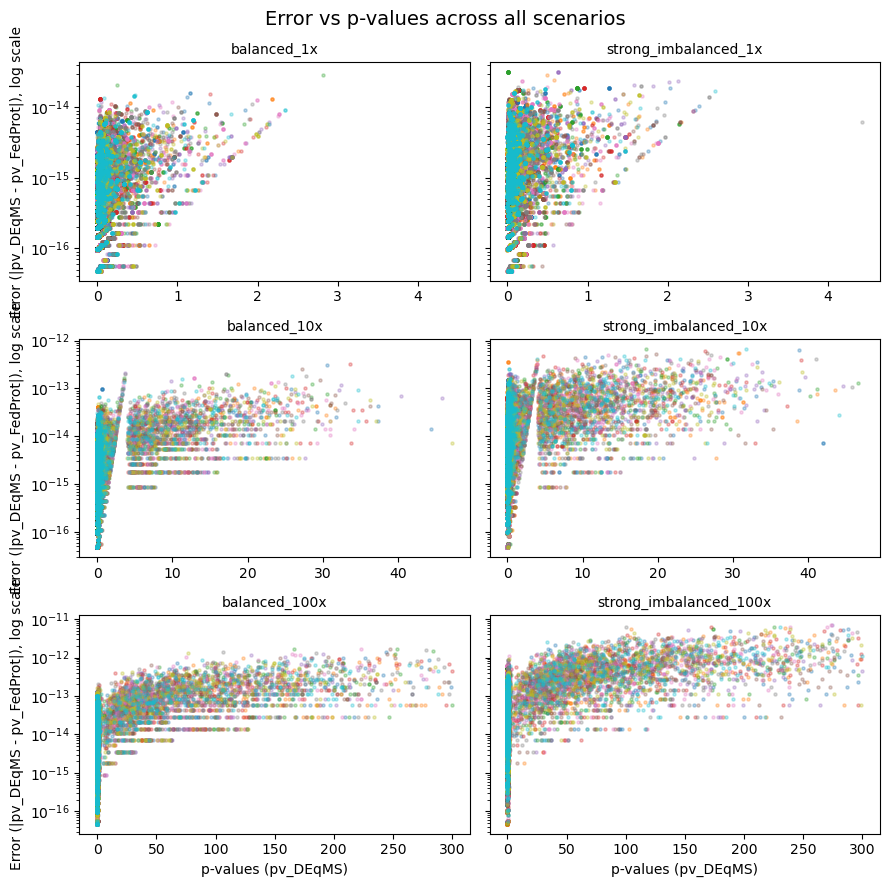

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# List of modes/scenarios
modes = [
    "balanced_1x", "balanced_10x", "balanced_100x",
    "strong_imbalanced_1x", "strong_imbalanced_10x", "strong_imbalanced_100x"
]

# Define your root directory and number of runs
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/simulated_scaled"
number_of_runs = 11  # runs 1 to 10

# Create a mapping from the x-factor to a row index.
row_mapping = {'1x': 0, '10x': 1, '100x': 2}

# Set up the subplot grid: 3 rows (for 1x, 10x, 100x) x 2 columns (balanced vs. strong_imbalanced)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(9, 9), sharex='row', sharey='row')

# Loop over each mode
for mode in modes:
    # Determine subplot position based on mode:
    #   Column: 0 for balanced, 1 for strong_imbalanced.
    #   Row: determined by the x-factor (e.g., "1x", "10x", or "100x")
    col = 0 if mode.startswith("balanced") else 1

    # Extract the x-factor from the mode (assumes the last part is "1x", "10x", or "100x")
    factor = mode.split('_')[-1]
    row = row_mapping[factor]

    # Construct the working directory for this mode.
    workdir = os.path.join(root_dir, mode, "results")

    # Initialize a dictionary to collect data points across runs
    all_data = {"Run": [], "Error": [], "PValue": [], "PG_name": []}

    # Loop over runs (runs 1 to 10)
    for i in range(1, number_of_runs):
        prefix = f"/{i}_"
        df = read_data(workdir, prefix)
        log_df = log_transform_df(df)
        
        # Compute error as the absolute difference between pv_DEqMS and pv_FedProt.
        error = np.abs(log_df["pv_DEqMS"] - log_df["pv_FedProt"])
        p_vals = log_df["pv_DEqMS"]
        
        # Store all the data points for this run.
        all_data["Run"].extend([i] * len(error))
        all_data["Error"].extend(error)
        all_data["PValue"].extend(p_vals)
        all_data['PG_name'].extend(log_df.index)

    # Convert collected data into a DataFrame and filter out points with zero error.
    all_data_df = pd.DataFrame(all_data)
    # all_data_df = all_data_df[all_data_df["Error"] > 0]

    # Plot data in the corresponding subplot.
    ax = axes[row, col]
    unique_runs = all_data_df["Run"].unique()
    for run in unique_runs:
        run_data = all_data_df[all_data_df["Run"] == run]
        ax.scatter(run_data["PValue"], run_data["Error"], alpha=0.3, s=5)

    # Set y-axis to log scale
    ax.set_yscale('log')

    # Set subplot title
    ax.set_title(f"{mode}", fontsize=10)

    # Set x-axis and y-axis labels only for the leftmost and bottom subplots
    if col == 0:
        ax.set_ylabel("Error (|pv_DEqMS - pv_FedProt|), log scale")
    if row == 2:
        ax.set_xlabel("p-values (pv_DEqMS)")

# Optionally, adjust layout and add a super title
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.suptitle("Error vs p-values across all scenarios", fontsize=14)
plt.show()
